##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import torch
import torch.nn.functional as F
import sklearn.cluster._kmeans as sklearn_kmeans
from contextlib import nullcontext
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from torchvision.datasets import OxfordIIITPet
from transformers import AutoImageProcessor, AutoModel

# Work around a local macOS/OpenBLAS threadpoolctl issue while still using sklearn KMeans.
sklearn_kmeans.threadpool_info = lambda: []
sklearn_kmeans.threadpool_limits = lambda *args, **kwargs: nullcontext()

MODEL_ID = "facebook/dinov2-small"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

pet_dataset = OxfordIIITPet(
    root="data/oxford-iiit-pet",
    split="trainval",
    target_types="category",
    download=True,
)

CAT_BREEDS = {
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair", "Egyptian Mau",
    "Maine Coon", "Persian", "Ragdoll", "Russian Blue", "Siamese", "Sphynx",
}

def cat_or_dog(category_index):
    class_name = pet_dataset.classes[category_index]
    return "cat" if class_name in CAT_BREEDS else "dog"

selected_samples = []
class_counts = {"cat": 0, "dog": 0}
selected_breeds = {"cat": set(), "dog": set()}

for image, category_index in pet_dataset:
    label = cat_or_dog(category_index)
    breed_name = pet_dataset.classes[category_index]
    if class_counts[label] < 10 and breed_name not in selected_breeds[label]:
        selected_samples.append((image.convert("RGB"), label, breed_name))
        class_counts[label] += 1
        selected_breeds[label].add(breed_name)
    if class_counts["cat"] == 10 and class_counts["dog"] == 10:
        break

@torch.no_grad()
def get_cls_token(image):
    inputs = processor(images=image, return_tensors="pt").to(device)
    outputs = model(**inputs)
    cls_token = outputs.last_hidden_state[:, 0]
    return F.normalize(cls_token, p=2, dim=1).cpu().numpy().squeeze()

cls_tokens = np.stack([get_cls_token(image) for image, _, _ in selected_samples])
true_labels = np.array([label for _, label, _ in selected_samples])
true_binary = np.array([0 if label == "cat" else 1 for label in true_labels])

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(cls_tokens)

# K-Means cluster numbers are arbitrary, so map each cluster to its majority ground-truth label.
cluster_to_binary = {}
for cluster_id in np.unique(cluster_ids):
    members = true_binary[cluster_ids == cluster_id]
    cluster_to_binary[cluster_id] = int(np.round(members.mean()))

pred_binary = np.array([cluster_to_binary[cluster_id] for cluster_id in cluster_ids])
pred_labels = np.array(["cat" if label == 0 else "dog" for label in pred_binary])

print(f"CLS token matrix shape: {cls_tokens.shape}")
print(f"Selected images: {class_counts['cat']} cats and {class_counts['dog']} dogs")
print(f"Clustering accuracy: {accuracy_score(true_binary, pred_binary):.2%}")
print("Confusion matrix rows=true [cat, dog], columns=predicted [cat, dog]:")
print(confusion_matrix(true_binary, pred_binary, labels=[0, 1]))

for idx, (_, true_label, breed_name) in enumerate(selected_samples):
    print(
        f"{idx + 1:02d}. {breed_name:22s} true={true_label:3s} "
        f"cluster={cluster_ids[idx]} predicted={pred_labels[idx]}"
    )

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CLS token matrix shape: (20, 384)
Selected images: 10 cats and 10 dogs
Clustering accuracy: 95.00%
Confusion matrix rows=true [cat, dog], columns=predicted [cat, dog]:
[[ 9  1]
 [ 0 10]]
01. Abyssinian             true=cat cluster=0 predicted=cat
02. American Bulldog       true=dog cluster=1 predicted=dog
03. American Pit Bull Terrier true=dog cluster=1 predicted=dog
04. Basset Hound           true=dog cluster=1 predicted=dog
05. Beagle                 true=dog cluster=1 predicted=dog
06. Bengal                 true=cat cluster=0 predicted=cat
07. Birman                 true=cat cluster=0 predicted=cat
08. Bombay                 true=cat cluster=0 predicted=cat
09. Boxer                  true=dog cluster=1 predicted=dog
10. British Shorthair      true=cat cluster=0 predicted=cat
11. Chihuahua              true=dog cluster=1 predicted=dog
12. Egyptian Mau           true=cat cluster=1 predicted=dog
13. English Cocker Spaniel true=dog cluster=1 predicted=dog
14. English Setter         tru

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

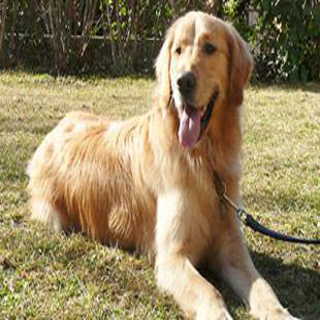

Image URL: https://images.dog.ceo/breeds/retriever-golden/n02099601_3004.jpg
Top-5 ImageNet predictions:
1. golden retriever: 97.47%
2. Labrador retriever: 0.38%
3. English setter: 0.35%
4. otterhound, otter hound: 0.30%
5. tennis ball: 0.23%


In [2]:
import requests
import torch
from io import BytesIO
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

CLASSIFICATION_MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
device = "cuda" if torch.cuda.is_available() else "cpu"

classification_processor = AutoImageProcessor.from_pretrained(CLASSIFICATION_MODEL_ID)
classification_model = AutoModelForImageClassification.from_pretrained(
    CLASSIFICATION_MODEL_ID
).to(device)
classification_model.eval()

# Online ImageNet-style example: a golden retriever.
image_url = "https://images.dog.ceo/breeds/retriever-golden/n02099601_3004.jpg"
response = requests.get(image_url, timeout=20)
response.raise_for_status()
image = Image.open(BytesIO(response.content)).convert("RGB")
display(image.resize((320, 320)))

inputs = classification_processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    logits = classification_model(**inputs).logits
    probabilities = torch.softmax(logits, dim=-1)
    top_probabilities, top_indices = torch.topk(probabilities, k=5, dim=-1)

print(f"Image URL: {image_url}")
print("Top-5 ImageNet predictions:")
for rank, (probability, class_index) in enumerate(
    zip(top_probabilities[0], top_indices[0]), start=1
):
    label = classification_model.config.id2label[class_index.item()]
    print(f"{rank}. {label}: {probability.item():.2%}")